In [1]:
import datetime as dt
import numpy as np
from numpy import datetime64 as dt
from numpy import timedelta64 as td
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt

import xarray as xr
import warnings
import pandas as pd
import geopandas as gpd

import scipy
from scipy.spatial import Voronoi, voronoi_plot_2d, ConvexHull, SphericalVoronoi
import cartopy.crs as ccrs
from cartopy.crs import Geodetic
import cartopy

warnings.simplefilter("ignore")

In [2]:
# Plot relevant parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = ccrs.Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [18]:
# Samplepoint parameters
samples = [
    "KB03", "SW08", "BE01", "GD01", "IU07", "LL17", "FI01", "SK02", "WH02", "KG01", "KG02",
    "SR01", "SR02", "JB01", "DB01", "DB02", "BP01", "BP02", "EG01", "EG02", "SR03", "WG01", 
    "WG02", "BP03", "BB23", "BB36", "GB96", "HR21"]
sample_lats = [ 
    54.692, 54.413, 54.5169,54.5829,59.489, 59.02,  59.77,  54.11,  53.637, 56.35,  57,
    58,     57.5,   56.5,   55.5,   54.5,   55.5,   56.1,   57.4,   58.3,   58.3,   57, 
    58.5,   55.4,   55.2912,54.9589,56.9165,54.9433,]
sample_lons = [
    10.1035,11.617, 10.034, 18.6042,21.2021,21.0478,23.2663,8.5,    8.15,    11.8,   11.5,
    10.5,   8,      7.2,    7,      7.4,    17.2,   18.5,   20.2,   20.6,   9.3,    17.4, 
    18.5,   19.3,   15.7503,15.9981,19.5827,13.4914,  ]
sample_kinds = [
    "real", "real", "real", "real", "real", "real", "real", "moved", "moved", "digital", "digital",
    "digital", "digital", "digital", "digital", "digital", "digital", "digital", "digital", "digital", "digital", "digital", 
    "digital", "digital", "real", "real", "real", "digital"]
order = [11, 13, 12, 19, 28, 27, 29, 1, 0, 10, 9, 7, 5, 4, 3, 2, 17, 18, 24, 25, 6, 21, 22, 20, 15, 16, 23, 14]


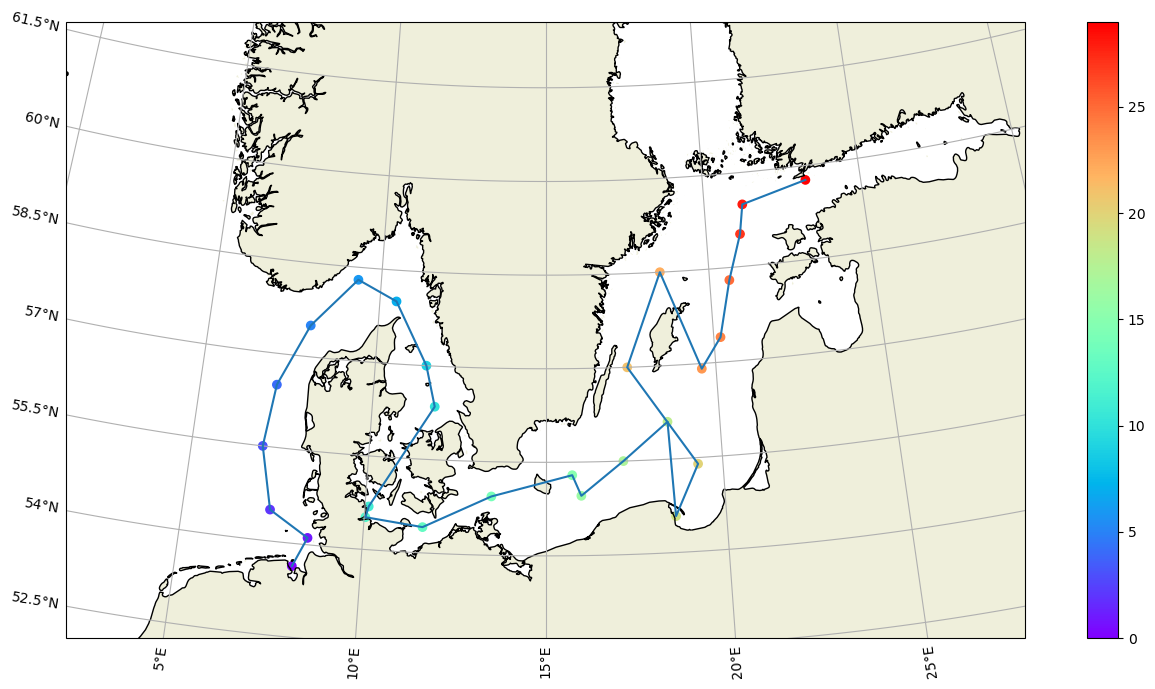

In [31]:
gdf_sorted = gdf_sample_points.sort_values("order")#.geometry.x
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_sample_points.plot(ax=ax_map, column="order", cmap='rainbow', legend=True)
ax_map.plot(gdf_sorted.geometry.x, gdf_sorted.geometry.y)
plt.show()

In [19]:
# define Paths
output_path = Path("/gxfs_work/geomar/smomw597/2025_copepods/output/SamplePoints")
output_SamplePoints = Path(output_path,"SamplePoints.shp")
output_VoronoiPolygons = Path(output_path,"VoronoiPolygons.shp")

In [20]:
# build geodataframe for sample points
sample_points = {
    'SampleID': samples, 
    'SampleKind': sample_kinds, 
    'order': order,
    'geometry': gpd.points_from_xy(sample_lons, sample_lats, crs=Geodetic()),
    }
gdf_sample_points = gpd.GeoDataFrame(sample_points).to_crs(map_projection)

In [22]:
# Define the the radius of interest around the sample points
centroid = gdf_sample_points.dissolve().centroid.to_crs(Geodetic())
area_of_interest = (
    gpd.GeoDataFrame(
        gdf_sample_points.SampleID,
        geometry=gdf_sample_points.to_crs(
            ccrs.Orthographic(
                # Set the central position of the Projection to the centroid
                central_longitude=centroid.x.values[0], 
                central_latitude=centroid.y.values[0]
                )
            )
        # Set the Bufferdistance to 125 000 metres
        .buffer(distance=1.25e5)
        # Reproject to the map projection
        .to_crs(map_projection)
        )
        # Dissolve the polygons to one single Polygon
        .dissolve()
    )

In [23]:
# Build geodataframe for voronoi polygons
gdf_voronoi = gdf_sample_points.voronoi_polygons()
sample_polygons = { 
    'geometry': gdf_voronoi,
    }
gdf_voronoi = gpd.GeoDataFrame(sample_polygons).to_crs(map_projection)

In [24]:
# Reorder the polygons so that the IDs are correct
gdf_voronoi_polygons = gpd.sjoin(left_df=gdf_voronoi, right_df=gdf_sample_points, how="left", rsuffix="polygon")
gdf_voronoi_polygons.rename(columns={'index_polygon':'index', 'SampleID': 'PolygonID'}, inplace = True)
gdf_voronoi_polygons = gdf_voronoi_polygons.set_index('index').sort_index()

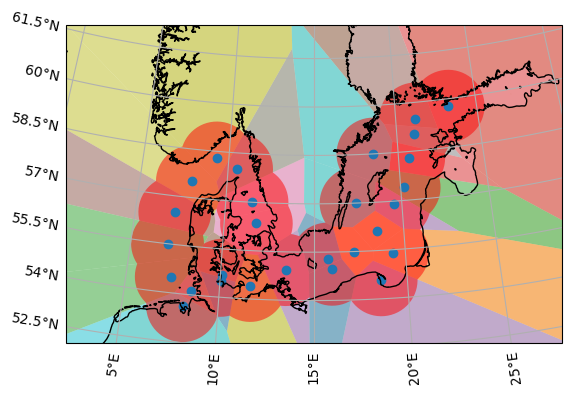

In [25]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.plot(ax=ax_map, alpha=0.5, column="PolygonID",)
area_of_interest.plot(ax=ax_map, alpha=0.5, color="r")
gdf_sample_points.plot(ax=ax_map)
plt.show()

In [26]:
gdf_voronoi_clipped = gdf_voronoi_polygons.clip(area_of_interest).sort_index()

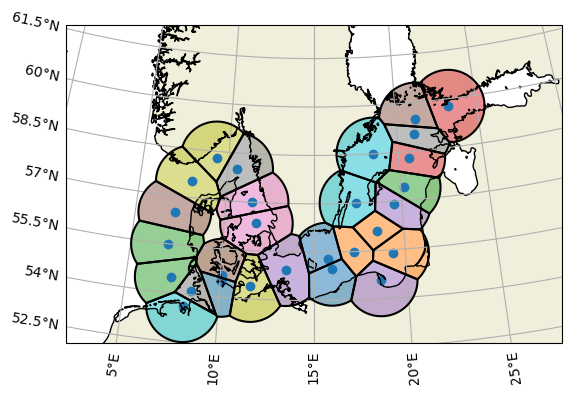

In [27]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_clipped.plot(ax=ax_map, alpha=0.5, column="PolygonID",)
gdf_voronoi_clipped.boundary.plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map)
plt.show()

In [28]:
gdf_voronoi_clipped.to_file(output_VoronoiPolygons)

In [29]:
gdf_sample_points.to_file(output_SamplePoints)

In [30]:
data_path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
data_path_static_fine = data_path_static_files / "static_file_fine"
data_path_static_coarse = data_path_static_files / "static_file_coarse"
H0_file_fine = data_path_static_fine / "H0_file_fine.nc"
H0_file_coarse = data_path_static_coarse / "H0_file_coarse.nc"
mask_land_fine = xr.open_dataset(H0_file_fine).H0.isnull()
mask_land_coarse = xr.open_dataset(H0_file_coarse).H0.isnull()

In [13]:
from shapely.geometry import Polygon
finebox = Polygon([
    (mask_land_fine.lon.min().values, mask_land_fine.lat.min().values),
    (mask_land_fine.lon.max().values, mask_land_fine.lat.min().values),
    (mask_land_fine.lon.max().values, mask_land_fine.lat.max().values),
    (mask_land_fine.lon.min().values, mask_land_fine.lat.max().values),
    (mask_land_fine.lon.min().values, mask_land_fine.lat.min().values),
    ])

In [14]:
coarsebox = Polygon([
    (mask_land_coarse.lon.min().values, mask_land_coarse.lat.min().values),
    (mask_land_coarse.lon.max().values, mask_land_coarse.lat.min().values),
    (mask_land_coarse.lon.max().values, mask_land_coarse.lat.max().values),
    (mask_land_coarse.lon.min().values, mask_land_coarse.lat.max().values),
    (mask_land_coarse.lon.min().values, mask_land_coarse.lat.min().values),
    ])

In [15]:
(mask_land_fine.lon.min().values, mask_land_fine.lat.min())


(array(6.1736),
 <xarray.DataArray 'lat' ()> Size: 8B
 array(53.2292))

In [16]:
gdf_land_fine = gpd.GeoDataFrame(
    mask_land_fine.to_dataframe().reset_index().H0,
    geometry=gpd.points_from_xy(
        mask_land_fine.to_dataframe().reset_index().lon,
        mask_land_fine.to_dataframe().reset_index().lat,
        crs=ccrs.Geodetic()
        )
    )
# mask_land_fine.to_dataframe().reset_index()

In [17]:
gdf_land_coarse = gpd.GeoDataFrame(
    mask_land_coarse.to_dataframe().reset_index().H0,
    geometry=gpd.points_from_xy(
        mask_land_coarse.to_dataframe().reset_index().lon,
        mask_land_coarse.to_dataframe().reset_index().lat,
        crs=ccrs.Geodetic()
        ).difference(finebox)
    )
# mask_land_fine.to_dataframe().reset_index()
# gdf_land_coarse = gdf_land_coarse.difference(finebox)


In [18]:
gdf_land = pd.concat([gdf_land_coarse,gdf_land_fine])

In [19]:
gdf_land = gdf_land.clip(gdf_voronoi_clipped.to_crs(Geodetic()))

<Axes: >

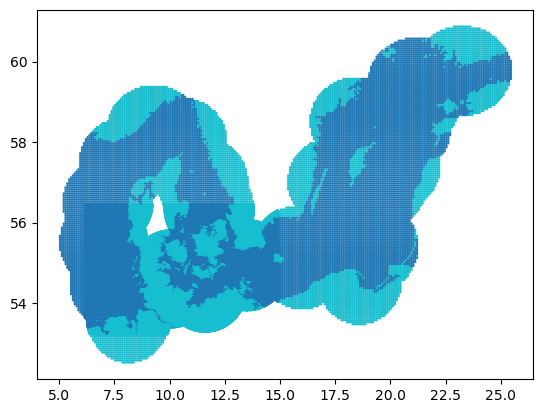

In [20]:
gdf_land.plot(column="H0", markersize=0.5)

In [21]:
voronoi_outlines_polygon = gdf_voronoi_clipped.to_crs(Geodetic()).polygonize()

In [30]:
gdf_land

,H0,geometry
238543,True,POINT (11.7708 53.2958)
238545,True,POINT (11.7986 53.2958)
238541,True,POINT (11.7431 53.2958)
238534,True,POINT (11.6458 53.2958)
237923,True,POINT (11.9097 53.3042)
...,...,...
69758,True,POINT (13.125 57.475)
69344,True,POINT (13.125 57.525)
68930,True,POINT (13.125 57.575)
68516,True,POINT (13.125 57.625)


In [31]:
gdf_land_raster = gpd.GeoDataFrame(
    gdf_land.H0,
    geometry=gdf_land.voronoi_polygons(
        extend_to=voronoi_outlines_polygon[0]
        )
)#.to_crs(Geodetic())

<Axes: >

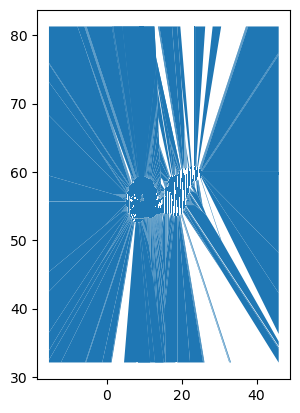

In [29]:
gdf_land_raster.plot()

<Axes: >

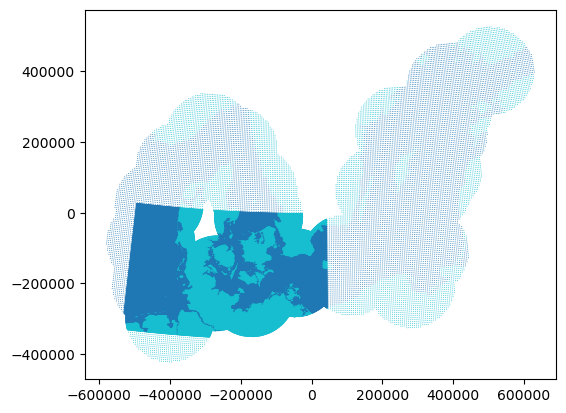

In [396]:
gpd.GeoDataFrame(
    gdf_land.H0,
    geometry=gdf_land.to_crs(
            ccrs.Orthographic(
                # Set the central position of the Projection to the centroid
                central_longitude=centroid.x.values[0], 
                central_latitude=centroid.y.values[0]
                )
            ).buffer(distance=1.25e3)
).plot(column="H0")

In [232]:
gdf_test_raster = gdf_land_raster.clip(gdf_voronoi_clipped.to_crs(Geodetic()))

<Axes: >

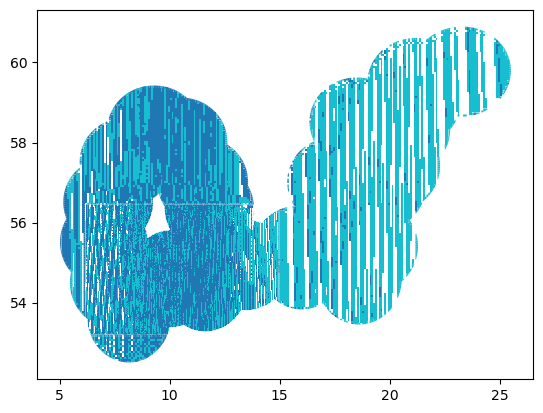

In [252]:
gdf_test_raster.plot(column="H0")

<Axes: >

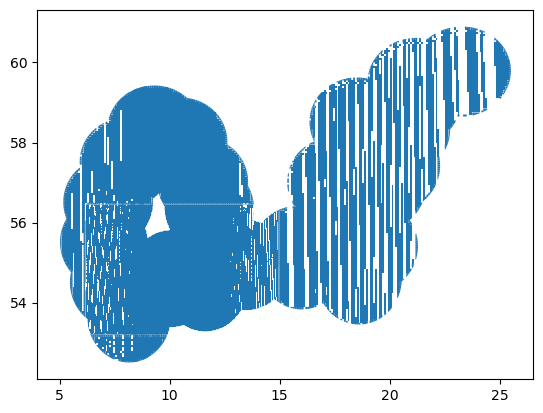

In [199]:
gdf_test_raster.plot()#.where(gdf_test_raster.H0==False).dropna().plot()

KeyboardInterrupt: 

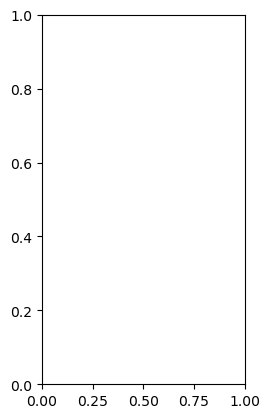

In [149]:
gdf_land_raster.where(gdf_land_raster.H0==True).plot()#.intersects(gdf_voronoi_clipped)
# gdf_voronoi_clipped.intersection(gdf_land_raster)

<Axes: >

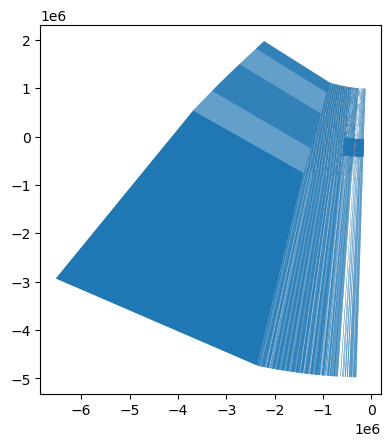

In [30]:
gdf_land_raster.where(gdf_land_raster.H0==True).dropna().plot()

In [267]:
gdf_voronoi_clipped.clip(mask_land_fine)

TypeError: If 'mask' is list-like, it must have four values (minx, miny, maxx, maxy)

In [32]:
df = ds_trajectories.get(["lat","lon"]).to_dataframe().reset_index().dropna()
print(df.size/1e9)

NameError: name 'ds_trajectories' is not defined

In [21]:
gdf_traj = gpd.GeoDataFrame(
    df.trajectory,
    geometry=gpd.points_from_xy(df.lon, df.lat, crs=ccrs.Geodetic())
    )

In [22]:
nrows_half = np.round(len(gdf_traj)/2).astype("int")

In [23]:
gdf_projected = gdf_traj[:nrows_half].to_crs(map_projection)
print("projected")
gdf_projected = gpd.sjoin(left_df=gdf_projected, right_df=gdf_voronoi, how="left", rsuffix="polygon")
print("joined")
gdf_projected_second = gdf_traj[nrows_half:].to_crs(map_projection)
print("projected")
gdf_projected_second = gpd.sjoin(left_df=gdf_projected_second, right_df=gdf_voronoi, how="left", rsuffix="polygon")
print("joined")

projected
joined
projected
joined


In [37]:
gdf_projected = pd.concat([gdf_projected, gdf_projected_second])

NameError: name 'gdf_projected' is not defined

NameError: name 'gdf_projected' is not defined

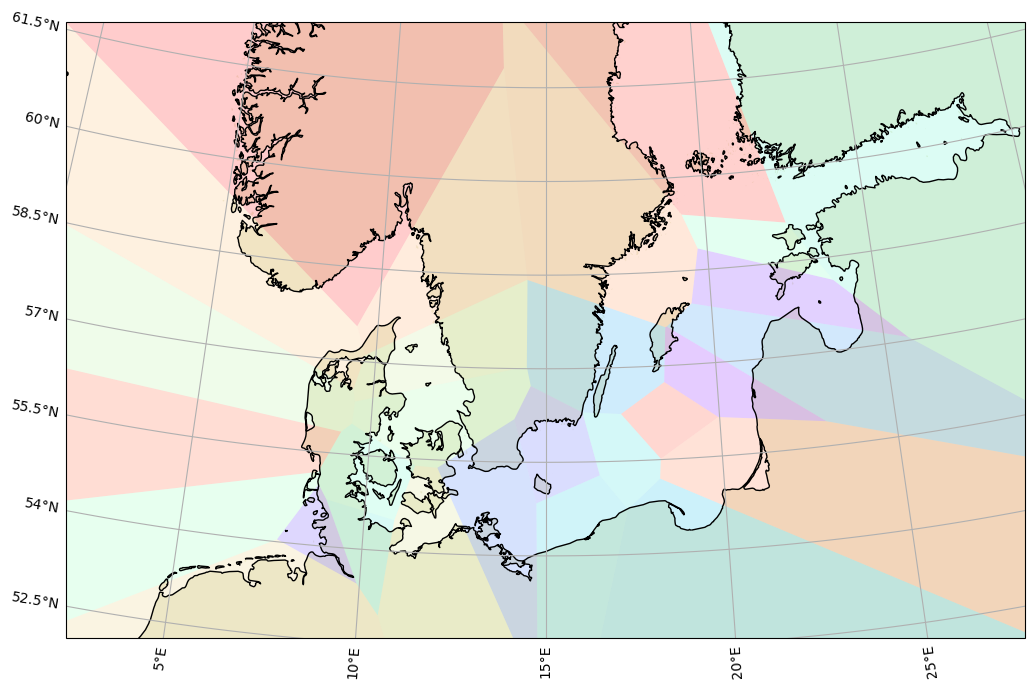

In [36]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi.to_crs(map_projection).plot(ax=ax_map,alpha=0.2, column="SampleID", cmap="rainbow")
gdf_projected[::24*400].plot(ax=ax_map, column="SampleID", cmap="rainbow", s=1)
gdf_voronoi.boundary.to_crs(map_projection).plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map, column="SampleKind", legend=True, )
plt.show()

<Axes: ylabel='Frequency'>

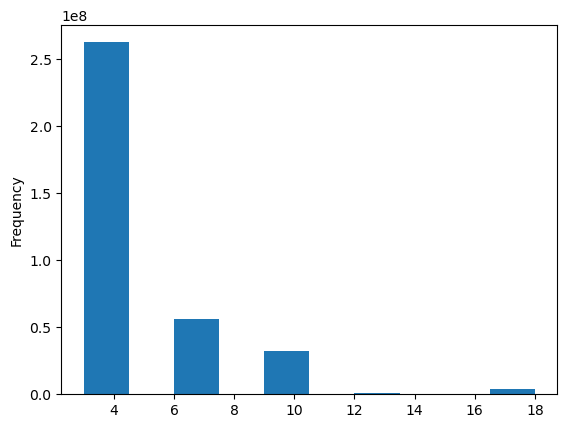

In [20]:
gdf_projected.index_polygon.plot.hist()

In [11]:
# save the data array to a file
# if isPapermill == True:
daily_data.to_netcdf(
    Path(out_path+f"ds_dispersal_{year}_{site_name}.nc")
)